In [39]:
import numpy as np
import pandas as pd

df_vendas = pd.read_csv("vendas_tech.csv", encoding="utf8", sep=",", low_memory=False)
#encoding="utf8" ou "latin1" (para mensagens em português, com acentos e afins)
#o separador por padrão do csv é a vírgula
df_gerentes = pd.read_excel("gerentes_lojas.xlsx")

display(df_vendas) #comando presente só no jupyter notebook

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Data_Base
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,2025-01-01
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,NaN
2,3,2023-02-25,NaN,"Monitor 27""",1200.0,1,Cliente_14859,NaN
3,4,2024-11-19,RIO DE JANEIRO,Mouse Gamer,120.0,2,Cliente_17343,NaN
4,5,2024-01-27,Rio de Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,NaN
...,...,...,...,...,...,...,...,...
100095,94091,2023-10-20,Porto Alegre,iPhone 14,5500.0,1,Cliente_11755,NaN
100096,52883,2024-03-17,Porto Alegre,Notebook Dell,3500.0,2,Cliente_12879,NaN
100097,65070,2023-06-19,Belo Horizonte,Smartphone Samsung,2200.0,2,Cliente_8160,NaN
100098,94031,2024-06-14,Salvador,iPhone 14,5500.0,2,Cliente_28545,NaN


In [2]:
#ferramentas de inspeção
#display(df_vendas)
#display(df_vendas.shape)
#display(df_vendas.head(9)) #primeiras linhas
#display(df_vendas.tail(5)) #últimas linhas

#display(df_vendas.sample(15)) #sem o index, são linhas aleatórias

display(df_vendas.columns)
#display(list(df_vendas.columns))

display(df_vendas.info())
display(df_vendas.describe())

Index(['ID_Pedido', 'Data', 'Loja', 'Produto', 'Preco_Unitario', 'Qtd',
       'Cliente', 'Data_Base'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100100 entries, 0 to 100099
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ID_Pedido       100100 non-null  int64  
 1   Data            100100 non-null  object 
 2   Loja            98099 non-null   object 
 3   Produto         100100 non-null  object 
 4   Preco_Unitario  100100 non-null  float64
 5   Qtd             100100 non-null  int64  
 6   Cliente         100100 non-null  object 
 7   Data_Base       1 non-null       object 
dtypes: float64(1), int64(2), object(5)
memory usage: 6.1+ MB


None

,ID_Pedido,Preco_Unitario,Qtd
count,100100.000000,100100.000000,100100.000000
mean,50004.810180,2000.204595,1.499101
std,28866.872543,1841.050733,1.241605
min,1.000000,40.000000,1.000000
25%,25008.750000,120.000000,1.000000
50%,50004.500000,1200.000000,1.000000
75%,75002.250000,3200.000000,1.000000
max,100000.000000,5500.000000,10.000000


In [40]:
# tratamento de dados
#display(df_vendas['Loja']) #selecionando uma coluna - uma série
#display(df_vendas[['Loja', 'Cliente']]) # duas colunas - um dataframe

### editar a nossa base de dados

# --------------- colunas -----------------------

#df_vendas = df_vendas[['Loja', 'Cliente']] #deixo meu df só com essas colunas
#df_vendas df_vendas.drop(columns=["Data_Base"]) #excluo só a coluna que eu desejo

#Para não mexer na minha df_vendas original, vou criar uma df para análise
#A gente só não faz a cópia se a base de dados for muito grande
df_analise = df_vendas.drop(columns=["Data_Base"])
#display(df_analise.columns)
display(df_analise.info())

# -------------- nulos ------------------------
#df_analise = df_analise.dropna() #exclui as linhas que contém NaN
df_analise["Loja"] = df_analise["Loja"].fillna("Online") #preencher os valores vazios com "Online"

# -------------- tipos de dados ---------------
df_analise["Data"] = pd.to_datetime(df_analise["Data"], format="%Y-%m-%d") #tipo datetime64 a partir de agora

# ------------- padronização de caracteres ---------
df_analise["Loja"] = df_analise["Loja"].str.strip() #remove espaços em lugares errados
df_analise["Loja"] = df_analise["Loja"].str.title() #padronizou pra ficar a primeira letra dessa coluna com letra maiúscula

df_gerentes["Loja"] = df_gerentes["Loja"].str.strip()
df_gerentes["Loja"] = df_gerentes["Loja"].str.title()


# ENCADEAMENTO: podemos resumir 3 passos anteriores no seguinte passo encadeado
#df_analise["Loja"] = df_analise["Loja"].fiillna("Online").str.strip().str.title()

#checagem de duplicatas
df_analise = df_analise.drop_duplicates(subset=["ID_Pedido", "Cliente"])
display(df_analise)
display(df_analise.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100100 entries, 0 to 100099
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ID_Pedido       100100 non-null  int64  
 1   Data            100100 non-null  object 
 2   Loja            98099 non-null   object 
 3   Produto         100100 non-null  object 
 4   Preco_Unitario  100100 non-null  float64
 5   Qtd             100100 non-null  int64  
 6   Cliente         100100 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 5.3+ MB


None

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377
...,...,...,...,...,...,...,...
99995,99996,2023-01-24,São Paulo,Mouse Gamer,120.0,2,Cliente_13732
99996,99997,2024-08-28,Rio De Janeiro,Cabo HDMI,40.0,1,Cliente_25058
99997,99998,2024-03-18,Curitiba,Smartphone Samsung,2200.0,2,Cliente_28864
99998,99999,2023-11-04,Porto Alegre,iPhone 14,5500.0,1,Cliente_4205


<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ID_Pedido       100000 non-null  int64         
 1   Data            100000 non-null  datetime64[ns]
 2   Loja            100000 non-null  object        
 3   Produto         100000 non-null  object        
 4   Preco_Unitario  100000 non-null  float64       
 5   Qtd             100000 non-null  int64         
 6   Cliente         100000 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 6.1+ MB


None

In [41]:
# Engenharia: criar colunas para analisar mais a fundo os dados que limpamos

# todas as informações que queremos analisar, devemos criar uma nova coluna para armazenar esses dados

# ------------- faturamento ------------------
df_analise["Faturamento"] = df_analise["Qtd"] * df_analise["Preco_Unitario"]

# ----------- forma de venda ------------------
df_analise["Forma_de_Venda"] = np.where(df_analise["Loja"] == "Online", "Online", "Presencial")

# ------------ região ------------------------
display(df_analise["Loja"].unique())

#sudeste = ["São Paulo", "Belo Horizonte", "Rio de Janeiro"] listas ou com dicionários

dic_regioes = {
    "São Paulo": "Sudeste",
    "Rio De Janeiro": "Sudeste",
    "Belo Horizonte": "Sudeste",
    "Salvador": "Nordeste",
    "Recife": "Nordeste",
    "Curitiba": "Sul",
    "Porto Alegre": "Sul",
    "Online": "Online"
}

#Se o mapeamento for mais complexo (como com mais condições), a gente pode gerar uma função fora, e dentro do map()
#chamar a função
df_analise["Região"] = df_analise["Loja"].map(dic_regioes)

display(df_analise)
display(df_analise.info())
display(df_analise.isna().sum())

array(['São Paulo', 'Belo Horizonte', 'Online', 'Rio De Janeiro',
       'Salvador', 'Recife', 'Curitiba', 'Porto Alegre'], dtype=object)

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_de_Venda,Região
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,120.0,Presencial,Sudeste
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,5500.0,Presencial,Sudeste
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859,1200.0,Online,Online
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343,240.0,Presencial,Sudeste
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,2200.0,Presencial,Sudeste
...,...,...,...,...,...,...,...,...,...,...
99995,99996,2023-01-24,São Paulo,Mouse Gamer,120.0,2,Cliente_13732,240.0,Presencial,Sudeste
99996,99997,2024-08-28,Rio De Janeiro,Cabo HDMI,40.0,1,Cliente_25058,40.0,Presencial,Sudeste
99997,99998,2024-03-18,Curitiba,Smartphone Samsung,2200.0,2,Cliente_28864,4400.0,Presencial,Sul
99998,99999,2023-11-04,Porto Alegre,iPhone 14,5500.0,1,Cliente_4205,5500.0,Presencial,Sul


<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ID_Pedido       100000 non-null  int64         
 1   Data            100000 non-null  datetime64[ns]
 2   Loja            100000 non-null  object        
 3   Produto         100000 non-null  object        
 4   Preco_Unitario  100000 non-null  float64       
 5   Qtd             100000 non-null  int64         
 6   Cliente         100000 non-null  object        
 7   Faturamento     100000 non-null  float64       
 8   Forma_de_Venda  100000 non-null  object        
 9   Região          100000 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 8.4+ MB


None

ID_Pedido         0
Data              0
Loja              0
Produto           0
Preco_Unitario    0
Qtd               0
Cliente           0
Faturamento       0
Forma_de_Venda    0
Região            0
dtype: int64

In [42]:
# ----------- analisar -> filtrar --------------
df_analise = df_analise.sort_values(by=["Data", "Faturamento"]) #ordenação de valores de forma decrescente
df_analise = df_analise.reset_index(drop=True) #o (drop=True) faz com que o índice seja resetado, jogando fora o índice antigo

display(df_analise)
#funções de localizar
#.loc - localiza pelo index (coluna 0) - nome da coluna e nome da linha
#Localizar, por ID_Pedido
id_pedido = 4

loja = df_analise.loc[3, "Loja"]
produto = df_analise.loc[3, "Produto"]
cliente = df_analise.loc[3, "Cliente"]
print(loja, produto, cliente)

loja = df_analise.loc[df_analise["ID_Pedido"]==4, "Loja"] #assim retorna subtabelas
produto = df_analise.loc[df_analise["ID_Pedido"]==4, "Produto"].values[0] #assim retorna só o valor
cliente = df_analise.loc[df_analise["ID_Pedido"]==4, "Cliente"].values[0]

print(loja, produto, cliente)

#.iloc - localizar em uma linha específica por posição
id_pedido = 4
loja = df_analise.iloc[3,2]
produto = df_analise.iloc[3,3]
cliente = df_analise.iloc[3,6]

print(loja, produto, cliente)

#condicional
#quando não temos uma noção específica (no caso anterior tínhamos o id_pedido especificado)
df_id_pedido_4 = df_analise[df_analise["ID_Pedido"]==4] #retorna a linha inteira


# ----------- exportar pedaços da base ----------
#exportar as vendas de São Paulo
df_vendas_sp = df_analise[df_analise["Loja"]=="São Paulo"]
df_vendas_sp.to_csv("Vendas_SP.csv", index=False) #exportar para .csv sem os índices

#exportar as vendas de 2024
df_vendas_2024 = df_analise[df_analise["Data"].dt.year==2024] #ou
#df_vendas_2024 = df_analise[df_analise["Data"] >= "2024-01-01"]

#duplas condições
df_vendas_HDMI_SUL = df_analise[(df_analise["Produto"]=="Cabo HDMI") & (df_analise["Região"]=="Sul")]


display(df_vendas_HDMI_SUL)


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_de_Venda,Região
0,1700,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_14435,40.0,Presencial,Sul
1,12848,2023-01-01,Belo Horizonte,Cabo HDMI,40.0,1,Cliente_4327,40.0,Presencial,Sudeste
2,35599,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_18680,40.0,Presencial,Sul
3,37130,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_22886,40.0,Presencial,Sul
4,49140,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_24445,40.0,Presencial,Sul
...,...,...,...,...,...,...,...,...,...,...
99995,43207,2024-12-30,Belo Horizonte,Notebook Dell,3500.0,2,Cliente_15893,7000.0,Presencial,Sudeste
99996,94455,2024-12-30,Curitiba,Notebook Dell,3500.0,2,Cliente_17419,7000.0,Presencial,Sul
99997,35192,2024-12-30,Salvador,iPhone 14,5500.0,2,Cliente_7615,11000.0,Presencial,Nordeste
99998,60794,2024-12-30,Rio De Janeiro,Smartphone Samsung,2200.0,5,Cliente_9964,11000.0,Presencial,Sudeste


Porto Alegre Cabo HDMI Cliente_22886
94164    Rio De Janeiro
Name: Loja, dtype: object Mouse Gamer Cliente_17343
Porto Alegre Cabo HDMI Cliente_22886


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_de_Venda,Região
0,1700,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_14435,40.0,Presencial,Sul
2,35599,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_18680,40.0,Presencial,Sul
3,37130,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_22886,40.0,Presencial,Sul
4,49140,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_24445,40.0,Presencial,Sul
9,70138,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_9348,40.0,Presencial,Sul
...,...,...,...,...,...,...,...,...,...,...
99874,75695,2024-12-30,Porto Alegre,Cabo HDMI,40.0,1,Cliente_29587,40.0,Presencial,Sul
99875,78584,2024-12-30,Curitiba,Cabo HDMI,40.0,1,Cliente_21307,40.0,Presencial,Sul
99880,35127,2024-12-30,Curitiba,Cabo HDMI,40.0,2,Cliente_20687,80.0,Presencial,Sul
99881,47774,2024-12-30,Porto Alegre,Cabo HDMI,40.0,2,Cliente_14363,80.0,Presencial,Sul


In [43]:
#Análises por agrupamento

#display(df_analise)

#ranking de faturamento por loja
analise_lojas = df_analise[["Loja", "Faturamento"]].groupby("Loja", as_index=False).sum()
analise_lojas = analise_lojas.sort_values(by="Faturamento", ascending=False)
analise_lojas = analise_lojas.reset_index(drop=True)

#analise_lojas["Faturamento"] = analise_lojas["Faturamento"].map("R${:,.2f}".format) #formatação do texto na tabela
display(analise_lojas)

#ranking de produtos que mais venderam no online
df_vendas_online = df_analise[df_analise["Loja"]=="Online"]
analise_produtos_online = df_vendas_online[["Produto", "Faturamento", "Qtd"]].groupby("Produto").sum()
analise_produtos_online = analise_produtos_online.sort_values(by="Faturamento", ascending=False) #ascending=False : do maior para o menor
#analise_produtos_online = analise_produtos_online.reset_index()
analise_produtos_online = analise_produtos_online.rename(columns={"Qtd": "Vendas Totais"}) #em geral a gente ajeita isso no começo da análise (T)

display(analise_produtos_online)

#analise de rankind por loja e por produto : a ordem faz diferença

#quais produtos venderam mais em cada uma das lojas
analise_produtos_em_lojas = df_analise[["Loja", "Produto", "Qtd"]].groupby(["Loja", "Produto"]).sum()


#quais lojas mais venderam cada produto, ou seja, vamos agrupar agora por produto
analise_lojas_por_produto = df_analise[["Loja", "Produto", "Qtd"]].groupby(["Produto", "Loja"]).sum()

#Lembrando que quando a gente faz o groupby(["Produto", "Loja"]), Produto e Loja viram índices
#Para exportar pra excel, a gente tem que dar um "reset_index()", sem o "drop=True"


#pd.set_option("display.max_rows", None) #aqui a gente pode configurar o máximo de linhas que o comando display vai exibir, ou neste caso, exibir todas
# --------------------------------------(None não configura limite)
with pd.option_context("display.max_rows", None): #estabelece a configuração apenas nesse contexto
    display(analise_produtos_em_lojas)
    display(analise_lojas_por_produto)

#display(analise_lojas)

,Loja,Faturamento
0,Salvador,42300610.0
1,Rio De Janeiro,42294720.0
2,Recife,42190390.0
3,São Paulo,42090690.0
4,Belo Horizonte,41714890.0
5,Porto Alegre,41678460.0
6,Curitiba,41121720.0
7,Online,6080850.0


,Faturamento,Vendas Totais
Produto,,
iPhone 14,2145000.0,390
Notebook HP,1414400.0,442
Notebook Dell,1291500.0,369
Smartphone Samsung,684200.0,311
"Monitor 27""",398400.0,332
Teclado Mecânico,85750.0,343
Mouse Gamer,45480.0,379
Cabo HDMI,16120.0,403


Qtd
Loja           Produto                 
Belo Horizonte Cabo HDMI           2636
               Monitor 27"         2625
               Mouse Gamer         2465
               Notebook Dell       2654
               Notebook HP         2775
               Smartphone Samsung  2597
               Teclado Mecânico    2609
               iPhone 14           2478
Curitiba       Cabo HDMI           2698
               Monitor 27"         2626
               Mouse Gamer         2600
               Notebook Dell       2517
               Notebook HP         2529
               Smartphone Samsung  2444
               Teclado Mecânico    2742
               iPhone 14           2652
Online         Cabo HDMI            403
               Monitor 27"          332
               Mouse Gamer          379
               Notebook Dell        369
               Notebook HP          442
               Smartphone Samsung   311
               Teclado Mecânico     343
               iPhone 14            390
Porto Alegre   Cabo HDMI           2571
               Monitor 27"         2655
               Mouse Gamer         2611
               Notebook Dell       2770
               Notebook HP         2511
               Smartphone Samsung  2603
               Teclado Mecânico    2598
               iPhone 14           2540
Recife         Cabo HDMI           2534
               Monitor 27"         2647
               Mouse Gamer         2639
               Notebook Dell       2566
               Notebook HP         2651
               Smartphone Samsung  2660
               Teclado Mecânico    2775
               iPhone 14           2652
Rio De Janeiro Cabo HDMI           2747
               Monitor 27"         2798
               Mouse Gamer         2652
               Notebook Dell       2534
               Notebook HP         2614
               Smartphone Samsung  2626
               Teclado Mecânico    2548
               iPhone 14           2702
Salvador       Cabo HDMI           2566
               Monitor 27"         2545
               Mouse Gamer         2711
               Notebook Dell       2512
               Notebook HP         2785
               Smartphone Samsung  2627
               Teclado Mecânico    2579
               iPhone 14           2671
São Paulo      Cabo HDMI           2649
               Monitor 27"         2796
               Mouse Gamer         2714
               Notebook Dell       2535
               Notebook HP         2592
               Smartphone Samsung  2476
               Teclado Mecânico    2589
               iPhone 14           2735

Qtd
Produto            Loja                
Cabo HDMI          Belo Horizonte  2636
                   Curitiba        2698
                   Online           403
                   Porto Alegre    2571
                   Recife          2534
                   Rio De Janeiro  2747
                   Salvador        2566
                   São Paulo       2649
Monitor 27"        Belo Horizonte  2625
                   Curitiba        2626
                   Online           332
                   Porto Alegre    2655
                   Recife          2647
                   Rio De Janeiro  2798
                   Salvador        2545
                   São Paulo       2796
Mouse Gamer        Belo Horizonte  2465
                   Curitiba        2600
                   Online           379
                   Porto Alegre    2611
                   Recife          2639
                   Rio De Janeiro  2652
                   Salvador        2711
                   São Paulo       2714
Notebook Dell      Belo Horizonte  2654
                   Curitiba        2517
                   Online           369
                   Porto Alegre    2770
                   Recife          2566
                   Rio De Janeiro  2534
                   Salvador        2512
                   São Paulo       2535
Notebook HP        Belo Horizonte  2775
                   Curitiba        2529
                   Online           442
                   Porto Alegre    2511
                   Recife          2651
                   Rio De Janeiro  2614
                   Salvador        2785
                   São Paulo       2592
Smartphone Samsung Belo Horizonte  2597
                   Curitiba        2444
                   Online           311
                   Porto Alegre    2603
                   Recife          2660
                   Rio De Janeiro  2626
                   Salvador        2627
                   São Paulo       2476
Teclado Mecânico   Belo Horizonte  2609
                   Curitiba        2742
                   Online           343
                   Porto Alegre    2598
                   Recife          2775
                   Rio De Janeiro  2548
                   Salvador        2579
                   São Paulo       2589
iPhone 14          Belo Horizonte  2478
                   Curitiba        2652
                   Online           390
                   Porto Alegre    2540
                   Recife          2652
                   Rio De Janeiro  2702
                   Salvador        2671
                   São Paulo       2735

In [45]:
#Analisar os gerentes que bateram as metas
#Como as metas dos gerentes são mensais, a gente tem que filtrar a tabela inicialmente por data

#quais gerentes bateram as metas em janeiro de 2023
df_meta = df_analise[(df_analise["Data"].dt.year == 2023) & (df_analise["Data"].dt.month==1)]

#agrupar o faturamento total por loja=gerente
#nesse caso é melhor primeiro agrupar e depois comparar com as informações de fora - da tabela dos gerentes
df_meta = df_meta[["Loja", "Faturamento"]].groupby("Loja", as_index=False).sum()
df_meta = df_meta.merge(df_gerentes, on="Loja", how="left") #juntar informações uma ao lado da outra (concatenar coloca uma abaixo da outra). o "how="left"" inclui a loja online
df_meta["Bateu Meta"] = np.where(df_meta["Faturamento"] >= df_meta["Meta_Mensal"], "Sim", "Não")
#se a coluna "Loja" não fosse compatível, e eu quisesse colocar uma coluna "Cidade" lá de "df_gerentes", eu posso escolher a posição da seguinte maneira:
#df_meta = df_meta.merge(df_gerentes, left_on="Loja", right_on="Cidade")

display(df_meta)

,Loja,Faturamento,Gerente,Meta_Mensal,Bateu Meta
0,Belo Horizonte,1779100.0,Juliana,55000.0,Sim
1,Curitiba,1986920.0,Roberto,45000.0,Sim
2,Online,404570.0,NaN,NaN,Não
3,Porto Alegre,1726640.0,Pedro,42000.0,Sim
4,Recife,1779020.0,Marcos,48000.0,Sim
5,Rio De Janeiro,1736830.0,Fernanda,60000.0,Sim
6,Salvador,1686070.0,Ana,52000.0,Sim
7,São Paulo,1831140.0,Carlos,50000.0,Sim


,Mes-Ano,Faturamento
0,2023-01,12930290.0
1,2023-02,11515150.0
2,2023-03,12516080.0
3,2023-04,12528900.0
4,2023-05,12940470.0
5,2023-06,12455820.0
6,2023-07,12550990.0
7,2023-08,12989130.0
8,2023-09,12118180.0
9,2023-10,12918990.0


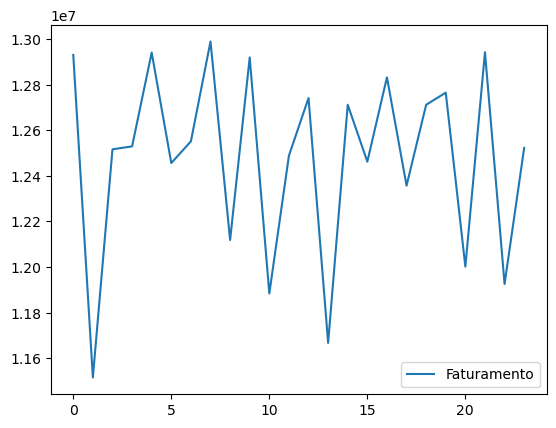

In [57]:
#Análise de série temporal : olhar tendências por mês ao longo do ano
df_analise["Mes-Ano"] = df_analise["Data"].dt.to_period("M")
df_vendas_mes = df_analise[["Faturamento", "Mes-Ano"]].groupby("Mes-Ano", as_index=False).sum()

df_vendas_mes.plot()

display(df_vendas_mes)


In [67]:
#Análise de série temporal : olhar tendências por mês ao longo do ano por loja
df_vendas_mes = df_analise[["Loja", "Faturamento", "Mes-Ano"]].groupby(["Loja", "Mes-Ano"], as_index=False).sum()

#df_vendas_mes.plot()

display(df_vendas_mes.head(15))


,Loja,Mes-Ano,Faturamento
0,Belo Horizonte,2023-01,1779100.0
1,Belo Horizonte,2023-02,1832950.0
2,Belo Horizonte,2023-03,1871600.0
3,Belo Horizonte,2023-04,1838640.0
4,Belo Horizonte,2023-05,1997800.0
5,Belo Horizonte,2023-06,1651980.0
6,Belo Horizonte,2023-07,1669270.0
7,Belo Horizonte,2023-08,1880960.0
8,Belo Horizonte,2023-09,1589220.0
9,Belo Horizonte,2023-10,1579310.0


In [ ]:
import matplotlib.pyplot as plt

df_vendas_mes_BH = df_vendas_mes[df_vendas_mes["Loja"]=="Belo Horizonte"]
display(df_vendas_mes_BH.info())


plt.plot(df_vendas_mes_BH["Mes-Ano"], df_vendas_mes_BH["Faturamento"])
plt.show()

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype    
---  ------       --------------  -----    
 0   Loja         24 non-null     object   
 1   Mes-Ano      24 non-null     period[M]
 2   Faturamento  24 non-null     float64  
dtypes: float64(1), object(1), period[M](1)
memory usage: 768.0+ bytes


None

TypeError: cannot convert the series to <class 'float'>